## Imports



In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from dataclasses import dataclass, field
from typing import List, Optional
import seaborn as sns
from performance_boosting import PBClosedLoop
from ren import ContractiveREN
from robot import RobotPlant, StabilizedRobot, PDController
from plot_functions import plot_pb_trajectories, plot_distance_tube
from dataset import generate_random_batch_old
from losses_and_wrappers import PBLoss, CVaRLossWrapper, SplitCVaRLossWrapper, LagrangianCVaRLossWrapper, LagrangianERMLossWrapper, ERMWrapper

## Simulation parameters

In [2]:
# --- 1. General Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Set seed
seed = 4
torch.manual_seed(seed)
np.random.seed(seed)

# --- 2. Dataset Parameters ---
x0_centers = [[-1.0, -1.0], [1.0, -1.0], [0.0, 1.0]]
x0_stds = [0.5, 0.2, 0.1]
x0_probs = [0.6, 0.3, 0.1]
noise_std = 0

 # --- 3. Physics & Model Parameters ---
n_agents = 1
state_dim = 4
input_dim = 2
dt = 0.05
#nominal model parameters
b_nom = 1
m_nom = 1
b2_nom = 0.2
#simulator parameters
b_sim = 1
m_sim = 1
b2_sim = 0.2

# --- 4. Base controller Parameters ---
x_target = torch.zeros(4 * n_agents)
kp = 1.
ki = 1.

# --- 5. REN Parameters ---
initialization_std = 0.01
dim_internal = 4
dim_nl = 4

# --- 5. Loss & Cost Parameters ---
#type of tracking and collision avoidance loss
track_mode='quadratic'
coll_mode = 'shifted_rbf'

# --- 5.1 Performance loss ---
#weight tracking
lambda_x = 10
# Base Q for 1 agent: Penalize pos_x, pos_y, vel_x, vel_y shape (4, 4)
Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * lambda_x
# Expand Q for N agents (Block Diagonal): (4 * n_agents, 4 * n_agents)
Q = torch.kron(torch.eye(n_agents), Q_agent)
#weight actuation
lambda_u = 0.
# Base R for 1 agent: Penalize force_x, force_y shape (2, 2)
R_agent = torch.eye(2) * lambda_u
# Expand R for N agents: (2 * n_agents, 2 * n_agents)
R = torch.kron(torch.eye(n_agents), R_agent)

# --- 5.2 Collision avoidance loss ---
# Weight for obstacle avoidance
lambda_obs = 50.0
#obstacles Parameters
obs_centers = [torch.tensor([0.5, -0.5]), torch.tensor([0., 0.6])]
obs_radii = [[0.1], [0.5, 0.1]]
safety_margin = 0.05
obs_radii_safe = [[r + safety_margin for r in obs] for obs in obs_radii]

# --- 6. Wrapper & Certification Parameters ---
decoupled_metrics = True
cvar_wrapper = True
conditional_training = False
#lambda for cvar training (if set to 1, same weight for collision term as in erm)
lambda_decoupling = 1
#desired safety threshold for lagrangian
tau_safe_bar = 0
#true certification goals
alpha_true = 0.05       # You want the real-world worst 5% targets 95% confidence
delta = 0.01            # With 99% confidence
m_cert = 2000           # Size of your final certification batch
#Calculate the penalty term (epsilon)
if conditional_training:
    epsilon_cert = np.sqrt(np.log(2 / delta) / (2 * m_cert))
else:
    epsilon_cert = 0
# Shift training alpha!
alpha_train = alpha_true - epsilon_cert

# --- 7. Training & Validation Parameters ---
num_training_steps = 1000
# Evaluate and print every log_interval steps
log_interval = 1
batch_size = 200
horizon = 500
lr = 0.001

# --- 7. Validation & Test Parameters ---
num_val_samples = 500
num_test_samples = 2000

## Fixed validation set

In [3]:
# Fixed validation set
fixed_val_w = generate_random_batch_old(batch_size = num_val_samples, horizon = horizon, n_agents= n_agents, x0_centers=x0_centers, x0_stds=x0_stds, x0_probs = x0_probs, noise_std = noise_std, device = device)
# Fixed test set
test_w = generate_random_batch_old(batch_size = num_test_samples, horizon = horizon, n_agents= n_agents, x0_centers=x0_centers, x0_stds=x0_stds, x0_probs = x0_probs, noise_std = noise_std, device = device)

## Simulator, nominal model and stabilizing controller

In [4]:
#Open loop real plant (unknown)
sim_OL_plant = RobotPlant(b = b_sim, b2 = b2_sim, m = m_sim, n_agents = n_agents).to(device)
#Open loop nominal model
nominal_OL_plant = RobotPlant(b = b_nom, b2 = b2_nom, m = m_nom, n_agents = n_agents).to(device)
#Proportional controller
base_controller = PDController(kp = kp, ki = ki, n_agents = n_agents).to(device)
#Stabilized real plant (closed loop of real plant and base controller) (unknown)
f_sim = StabilizedRobot(sim_OL_plant, base_controller).to(device)
#Stabilized nominal model (closed loop of nominal model and base controller) (I could use a different controller as long as this is a stable closed loop or if I use the base controller of the real plant I have to make sure it stabilizes my model as well)
f_nom = StabilizedRobot(nominal_OL_plant, base_controller).to(device)

#Freeze the physics/nominal models
for param in f_sim.parameters():
    param.requires_grad = False
for param in f_nom.parameters():
    param.requires_grad = False

## Empirical Risk Minimization training (no model mismatch)


### Define simulated model

In [5]:
#Ren
ren = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim = PBClosedLoop(ren, f_sim, f_nom).to(device)

### Training loop


Starting online training on cpu...


Training Steps:   0%|          | 0/1000 [00:00<?, ?it/s]

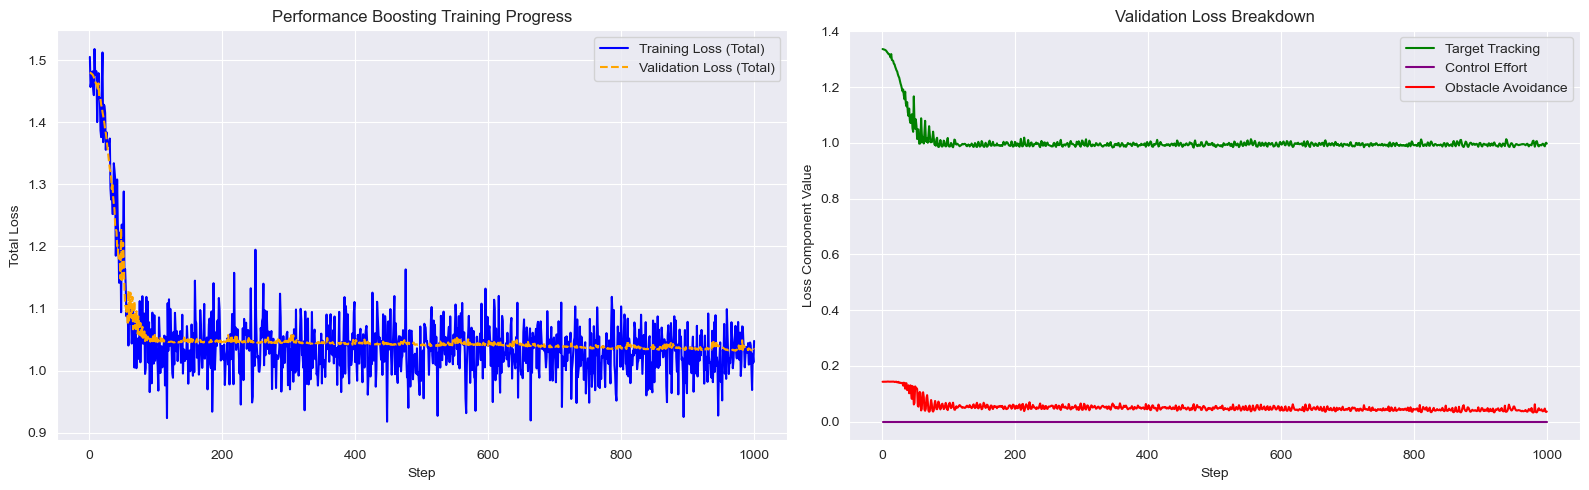

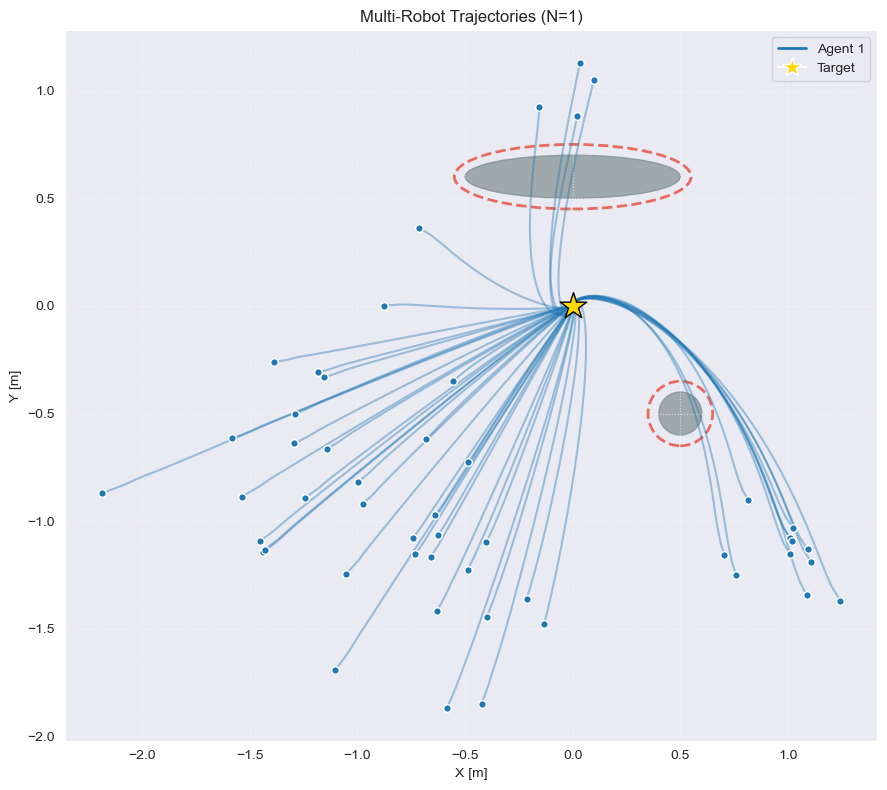

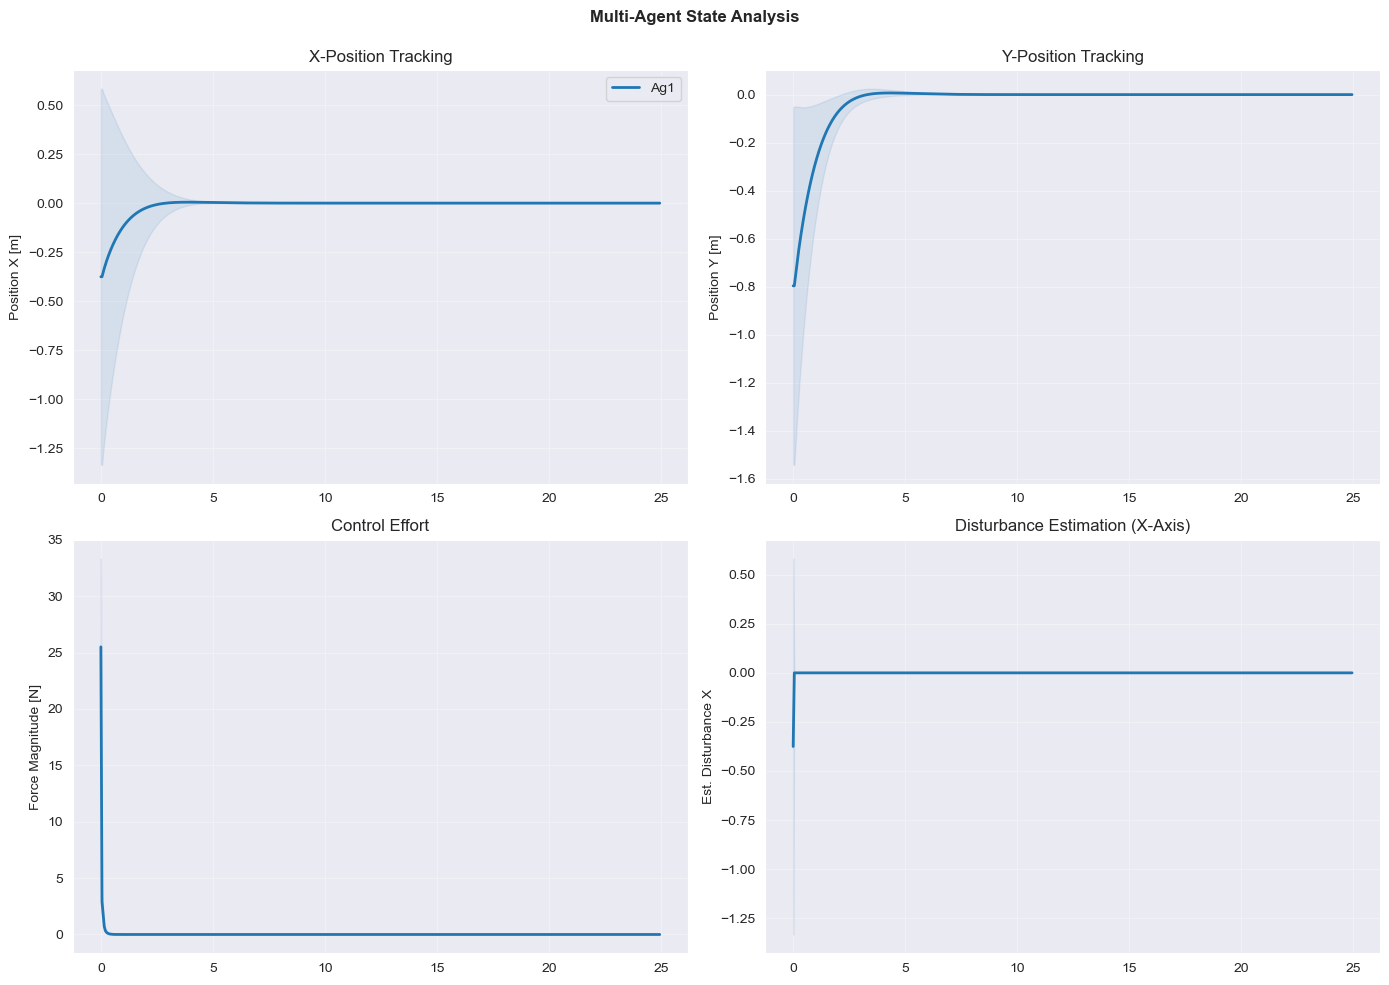

In [6]:
#Instantiate loss and Move to Device
metric = PBLoss(x_target, Q, R, lambda_obs, obs_centers, obs_radii_safe=obs_radii_safe, n_agents=n_agents, track_mode=track_mode, coll_mode = coll_mode)
metric.to(device) #Moves Q, R, target, and obstacles to GPU
loss_wrapper = ERMWrapper(metric)

optimizer = torch.optim.Adam(PB_closed_loop_sim.parameters(), lr=lr)

# Lists for plotting
train_losses = []
val_losses = []
val_loss_targets = []
val_loss_us = []
val_loss_obss = []

# Only store the very last batch's trajectories for plotting to save RAM
last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting online training on {device}...")

# Use tqdm for a nice progress bar
pbar = tqdm(range(num_training_steps), desc="Training Steps")

for step in pbar:
    # --- TRAINING PHASE ---
    PB_closed_loop_sim.train()
    optimizer.zero_grad()

    # 1. Generate fresh data
    batch_w = generate_random_batch_old(batch_size = batch_size, horizon = horizon, n_agents= n_agents, x0_centers=x0_centers, x0_stds=x0_stds, x0_probs = x0_probs, noise_std = noise_std, device = device)

    # 2. Run Sim & Compute Loss
    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim.run(batch_w)
    loss, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)

    # 3. Backprop
    loss.backward()
    optimizer.step()

    # --- VALIDATION & LOGGING ---
    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim.eval()

        with torch.no_grad():
            # Evaluate on FIXED validation set
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim.run(fixed_val_w)
            val_loss, val_target, val_u, val_obs = loss_wrapper(traj_x_val, traj_u_val)

        # Update lists for plotting
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        # Track individual components
        val_loss_targets.append(val_target.item())
        val_loss_us.append(val_u.item())
        val_loss_obss.append(val_obs.item())

        # Update progress bar metrics (adding obstacle loss here is usually very helpful for quick debugging)
        pbar.set_postfix({
            'Train Loss': f"{loss.item():.4f}",
            'Val Loss': f"{val_loss.item():.4f}",
            'Val Obs': f"{val_obs:.4f}"
        })

    if step == num_training_steps - 1:
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

# --- PLOTTING ---
steps = range(log_interval, num_training_steps + 1, log_interval)

# Create a 1x2 grid of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Total Traing vs Validation Loss
ax1.plot(steps, train_losses, label='Training Loss (Total)', color='blue')
ax1.plot(steps, val_losses, label='Validation Loss (Total)', color='orange', linestyle='--')
ax1.set_xlabel('Step')
ax1.set_ylabel('Total Loss')
ax1.set_title('Performance Boosting Training Progress')
ax1.legend()
ax1.grid(True)

# Plot 2: Validation Loss Breakdown
ax2.plot(steps, val_loss_targets, label='Target Tracking', color='green')
ax2.plot(steps, val_loss_us, label='Control Effort', color='purple')
ax2.plot(steps, val_loss_obss, label='Obstacle Avoidance', color='red')
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss Component Value')
ax2.set_title('Validation Loss Breakdown')
ax2.legend()
ax2.grid(True)

# Adjust layout to prevent overlap and show
plt.tight_layout()
plt.show()

plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe = obs_radii_safe,
    dt=dt
)

## Quantile-oriented training

### Define simulated model

In [7]:
#Ren
ren_cvar = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_cvar = PBClosedLoop(ren_cvar, f_sim, f_nom).to(device)

### Training loop

Starting online training on cpu...


CVaR Training Steps:   0%|          | 0/1000 [00:00<?, ?it/s]

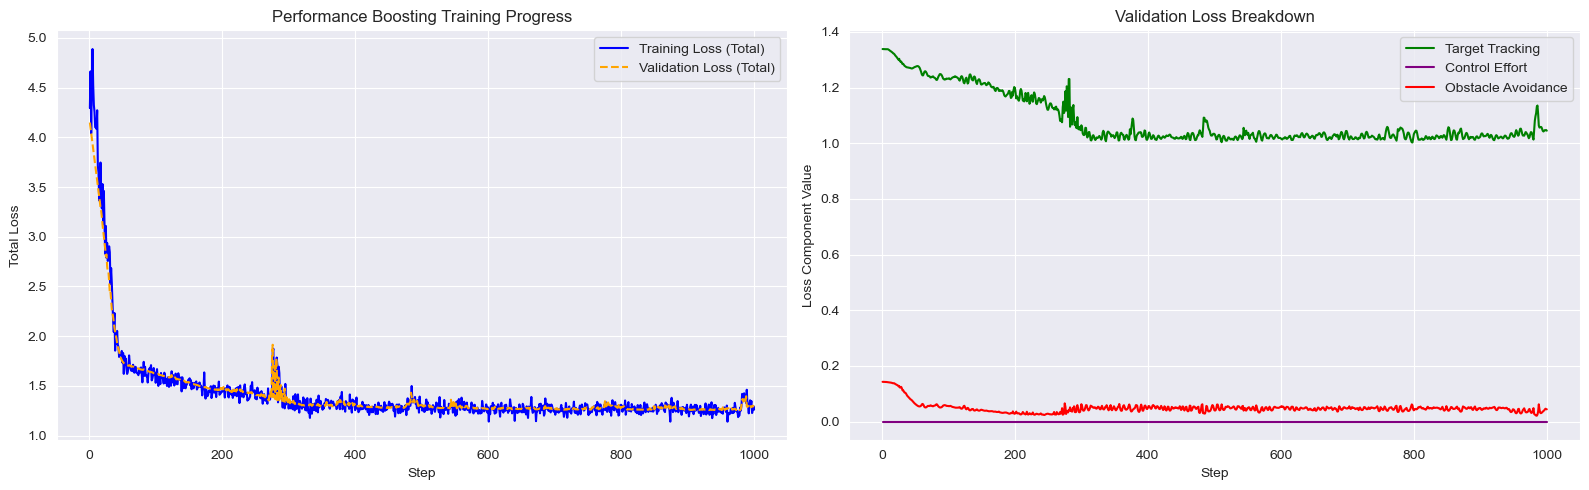

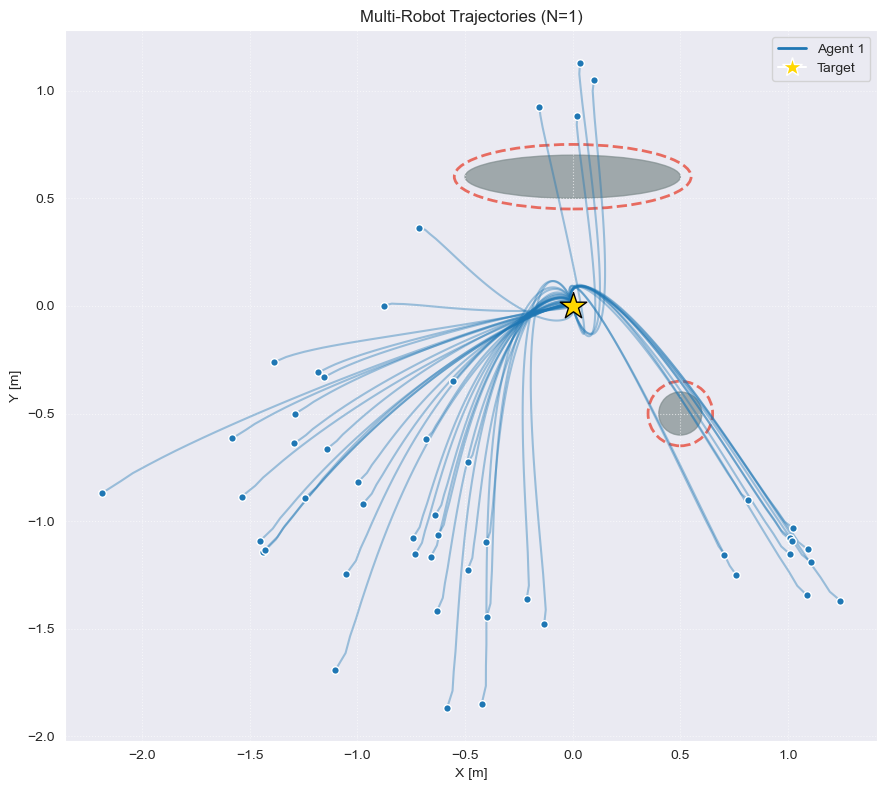

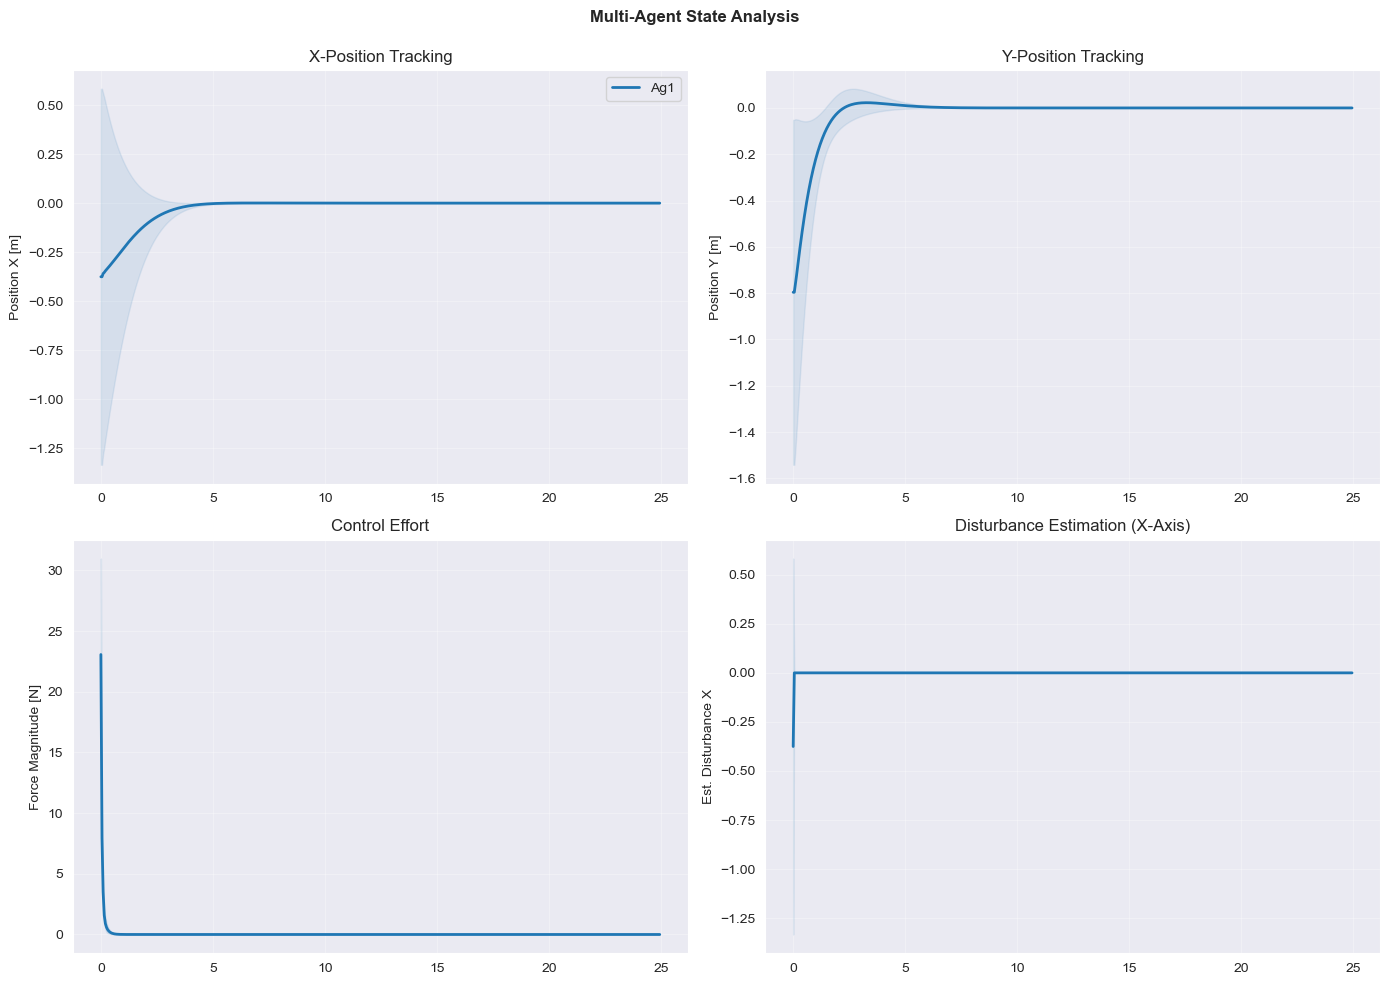

In [8]:
#Instantiate metric and Move to Device
metric = PBLoss(x_target, Q, R, lambda_obs, obs_centers, obs_radii_safe=obs_radii_safe, n_agents=n_agents, track_mode=track_mode, coll_mode = coll_mode)
metric.to(device)  #Moves Q, R, target, and obstacles to GPU

# 1. Setup Loss Wrapper
if decoupled_metrics:
    loss_wrapper = SplitCVaRLossWrapper(alpha = alpha_train, lambda_decoupling = lambda_decoupling, metric=metric)
else:
    loss_wrapper = CVaRLossWrapper(alpha=alpha_train, metric=metric)
loss_wrapper.to(device) # Moves tau to GPU

optimizer = torch.optim.Adam([
    # Medium Speed: Controller weights
    {'params': PB_closed_loop_sim_cvar.parameters(), 'lr': lr},
    # Fast Speed: Tau needs to track the quantile quickly
    {'params': [loss_wrapper.tau], 'lr': lr * 10.0,}
])

# Lists for plotting
train_losses = []
val_losses = []
val_loss_targets = []
val_loss_us = []
val_loss_obss = []

# Only store the very last batch's trajectories for plotting to save RAM
last_traj_x_train = None
last_traj_u_train = None
last_traj_w_hat_train = None

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting online training on {device}...")

# Use tqdm for a nice progress bar
pbar = tqdm(range(num_training_steps), desc="CVaR Training Steps")

for step in pbar:
    PB_closed_loop_sim_cvar.train()
    optimizer.zero_grad()

    batch_w = generate_random_batch_old(batch_size = batch_size, horizon = horizon, n_agents= n_agents, x0_centers=x0_centers, x0_stds=x0_stds, x0_probs = x0_probs, noise_std = noise_std, device = device)

    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_cvar.run(batch_w)
    # Wrapper returns (loss, raw_costs)
    loss, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)

    loss.backward()
    optimizer.step()

    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_cvar.eval()

        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_cvar.run(fixed_val_w)
            val_loss, val_target, val_u, val_obs = loss_wrapper(traj_x_val, traj_u_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        # Track individual components
        val_loss_targets.append(val_target.item())
        val_loss_us.append(val_u.item())
        val_loss_obss.append(val_obs.item())

        # Update progress bar metrics (adding obstacle loss here is usually very helpful for quick debugging)
        pbar.set_postfix({
            'CVaR Train': f"{loss.item():.4f}",
            'CVaR Val': f"{val_loss.item():.4f}",
            'Tau': f"{loss_wrapper.tau.item():.4f}",
            'Val Obs': f"{val_obs:.4f}"
        })

    if step == num_training_steps - 1:
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

# --- PLOTTING ---
steps = range(log_interval, num_training_steps + 1, log_interval)

# Create a 1x2 grid of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Total Traing vs Validation Loss
ax1.plot(steps, train_losses, label='Training Loss (Total)', color='blue')
ax1.plot(steps, val_losses, label='Validation Loss (Total)', color='orange', linestyle='--')
ax1.set_xlabel('Step')
ax1.set_ylabel('Total Loss')
ax1.set_title('Performance Boosting Training Progress')
ax1.legend()
ax1.grid(True)

# Plot 2: Validation Loss Breakdown
ax2.plot(steps, val_loss_targets, label='Target Tracking', color='green')
ax2.plot(steps, val_loss_us, label='Control Effort', color='purple')
ax2.plot(steps, val_loss_obss, label='Obstacle Avoidance', color='red')
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss Component Value')
ax2.set_title('Validation Loss Breakdown')
ax2.legend()
ax2.grid(True)

# Adjust layout to prevent overlap and show
plt.tight_layout()
plt.show()

plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe = obs_radii_safe,
    dt=dt
)

## Training ERM Lagrangian

### Define simulated model

In [9]:
#Ren
ren_lagrangian_ERM = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_lagrangian_ERM = PBClosedLoop(ren_lagrangian_ERM, f_sim, f_nom).to(device)

### Training loop


In [10]:
# ==========================================
# 1. Setup Metric and Wrapper
# ==========================================

metric = PBLoss(x_target, Q, R, lambda_obs, obs_centers, obs_radii_safe=obs_radii_safe, n_agents=n_agents, track_mode=track_mode, coll_mode = coll_mode)
metric.to(device)
loss_wrapper = LagrangianERMLossWrapper(alpha=alpha_train, tau_safe_bar=tau_safe_bar, metric=metric)
loss_wrapper.to(device)

# ==========================================
# 2. Setup Primal and Dual Optimizers
# ==========================================
# Primal Optimizer: Minimizes controller weights and tau
# Primal Optimizer: Uses Parameter Groups to separate speeds
opt_primal = torch.optim.Adam(PB_closed_loop_sim_lagrangian_ERM.parameters(), lr=lr)

# Dual Optimizer: Maximizes lambda (slightly higher LR??)
dual_params = [loss_wrapper.pre_lambda]
opt_dual = torch.optim.Adam(dual_params, lr=lr * 0.1, maximize=True)

# ==========================================
# 3. Training Loop setup
# ==========================================
# Lists for plotting
train_lagrangians_ERM = []
val_lagrangians_ERM = []
val_perfs_ERM = []
val_cvars_ERM = []
val_lambdas_ERM = []

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting Formulation 3 Dual-Ascent training on {device}...")
pbar = tqdm(range(num_training_steps), desc="Hard Constrained Training")

for step in pbar:
    PB_closed_loop_sim_lagrangian_ERM.train()

    # Zero both optimizers
    opt_primal.zero_grad()
    opt_dual.zero_grad()

    batch_w = generate_random_batch_old(batch_size=batch_size, horizon=horizon, n_agents=n_agents,
                                    x0_centers=x0_centers, x0_stds=x0_stds, x0_probs=x0_probs,
                                    noise_std=noise_std, device=device)

    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_lagrangian_ERM.run(batch_w)

    # Forward pass
    lagrangian, _, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)

    # Backward pass
    lagrangian.backward()

    # Step both optimizers
    opt_primal.step() # Steps in negative gradient direction
    opt_dual.step()   # Steps in positive gradient direction (because maximize=True)

    # ==========================================
    # 44. Validation and Logging
    # ==========================================
    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_lagrangian_ERM.eval()

        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_lagrangian_ERM.run(fixed_val_w)
            val_lag, val_perf, val_cvar, val_lam, val_viol = loss_wrapper(traj_x_val, traj_u_val)

        train_lagrangians_ERM.append(lagrangian.item())
        val_lagrangians_ERM.append(val_lag.item())

        # FIX: val_perf is already a float, so just append it directly
        val_perfs_ERM.append(val_perf.item())
        val_cvars_ERM.append(val_cvar.item())
        val_lambdas_ERM.append(val_lam.item())

        # FIX: Remove .item() from val_perf here as well
        pbar.set_postfix({
            'Perf': f"{val_perf:.2f}",
            'CVaR Safe': f"{val_cvar:.2f}",
            'Viol': f"{val_viol:.2f}",
            'Lambda': f"{val_lam:.3f}"
        })


    if step == num_training_steps - 1:
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

# ==========================================
# 5. Plotting Results
# ==========================================
steps = range(log_interval, num_training_steps + 1, log_interval)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Lagrangian Loss
ax1.plot(steps, train_lagrangians_ERM, label='Train Lagrangian', color='blue')
ax1.plot(steps, val_lagrangians_ERM, label='Val Lagrangian', color='orange', linestyle='--')
ax1.set_xlabel('Step')
ax1.set_ylabel('Lagrangian Loss')
ax1.set_title('Min-Max Convergence')
ax1.legend()
ax1.grid(True)

# Plot 2: Performance vs Safety Constraint
ax2.plot(steps, val_perfs_ERM, label='Expected Perf (Minimize)', color='green')
ax2.plot(steps, val_cvars_ERM, label='CVaR Collision', color='red')
ax2.axhline(y=tau_safe_bar, color='red', linestyle=':', label='Max Safe CVaR (Tau_bar)')
ax2.set_xlabel('Step')
ax2.set_ylabel('Cost')
ax2.set_title('Performance vs. Hard Safety Constraint')
ax2.legend()
ax2.grid(True)

# Plot 3: Dual Variable (Lambda)
ax3.plot(steps, val_lambdas_ERM, label='Lambda (Dual Var)', color='purple')
ax3.set_xlabel('Step')
ax3.set_ylabel('Lambda Penalty Weight')
ax3.set_title('Dual Variable Adaptation')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe = obs_radii_safe,
    dt=dt
)

Starting Formulation 3 Dual-Ascent training on cpu...


Hard Constrained Training:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Training Cvar Lagrangian

### Define simulated model


In [ ]:
#Ren
ren_lagrangian = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_lagrangian = PBClosedLoop(ren_lagrangian, f_sim, f_nom).to(device)

### Training loop

In [ ]:
# ==========================================
# 1. Setup Metric and Wrapper
# ==========================================

metric = PBLoss(x_target, Q, R, lambda_obs, obs_centers, obs_radii_safe=obs_radii_safe, n_agents=n_agents, track_mode=track_mode, coll_mode = coll_mode)
metric.to(device)
loss_wrapper = LagrangianCVaRLossWrapper(alpha=alpha_train, tau_safe_bar=tau_safe_bar, metric=metric)
loss_wrapper.to(device)

# ==========================================
# 2. Setup Primal and Dual Optimizers
# ==========================================
# Primal Optimizer: Minimizes controller weights and tau
# Primal Optimizer: Uses Parameter Groups to separate speeds
opt_primal = torch.optim.Adam([
    # Medium Speed: Controller weights
    {'params': PB_closed_loop_sim_lagrangian.parameters(), 'lr': lr},
    # Fast Speed: Tau needs to track the quantile quickly
    {'params': [loss_wrapper.tau], 'lr': lr * 10.0,}
])

# Dual Optimizer: Maximizes lambda
dual_params = [loss_wrapper.pre_lambda]
opt_dual = torch.optim.Adam(dual_params, lr=lr * 0.1, maximize=True)

# ==========================================
# 3. Training Loop setup
# ==========================================
# Lists for plotting
train_lagrangians = []
val_lagrangians = []
val_perfs = []
val_cvars = []
val_lambdas = []

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting Formulation 3 Dual-Ascent training on {device}...")
pbar = tqdm(range(num_training_steps), desc="Hard Constrained Training")

for step in pbar:
    PB_closed_loop_sim_lagrangian.train()

    # Zero both optimizers
    opt_primal.zero_grad()
    opt_dual.zero_grad()

    batch_w = generate_random_batch_old(batch_size=batch_size, horizon=horizon, n_agents=n_agents,
                                    x0_centers=x0_centers, x0_stds=x0_stds, x0_probs=x0_probs,
                                    noise_std=noise_std, device=device)

    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_lagrangian.run(batch_w)

    # Forward pass
    lagrangian, _, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)

    # Backward pass
    lagrangian.backward()

    # Step both optimizers
    opt_primal.step() # Steps in negative gradient direction
    opt_dual.step()   # Steps in positive gradient direction (because maximize=True)

    # ==========================================
    # 44. Validation and Logging
    # ==========================================
    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_lagrangian.eval()

        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_lagrangian.run(fixed_val_w)
            val_lag, val_perf, val_cvar, val_lam, val_viol = loss_wrapper(traj_x_val, traj_u_val)

        train_lagrangians.append(lagrangian.item())
        val_lagrangians.append(val_lag.item())

        # FIX: val_perf is already a float, so just append it directly
        val_perfs.append(val_perf.item())
        val_cvars.append(val_cvar.item())
        val_lambdas.append(val_lam.item())

        # FIX: Remove .item() from val_perf here as well
        pbar.set_postfix({
            'Perf': f"{val_perf:.2f}",
            'CVaR Safe': f"{val_cvar:.2f}",
            'Viol': f"{val_viol:.2f}",
            'Lambda': f"{val_lam:.3f}"
        })


    if step == num_training_steps - 1:
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

# ==========================================
# 5. Plotting Results
# ==========================================
steps = range(log_interval, num_training_steps + 1, log_interval)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Lagrangian Loss
ax1.plot(steps, train_lagrangians, label='Train Lagrangian', color='blue')
ax1.plot(steps, val_lagrangians, label='Val Lagrangian', color='orange', linestyle='--')
ax1.set_xlabel('Step')
ax1.set_ylabel('Lagrangian Loss')
ax1.set_title('Min-Max Convergence')
ax1.legend()
ax1.grid(True)

# Plot 2: Performance vs Safety Constraint
ax2.plot(steps, val_perfs, label='Expected Perf (Minimize)', color='green')
ax2.plot(steps, val_cvars, label='CVaR Collision', color='red')
ax2.axhline(y=tau_safe_bar, color='red', linestyle=':', label='Max Safe CVaR (Tau_bar)')
ax2.set_xlabel('Step')
ax2.set_ylabel('Cost')
ax2.set_title('Performance vs. Hard Safety Constraint')
ax2.legend()
ax2.grid(True)

# Plot 3: Dual Variable (Lambda)
ax3.plot(steps, val_lambdas, label='Lambda (Dual Var)', color='purple')
ax3.set_xlabel('Step')
ax3.set_ylabel('Lambda Penalty Weight')
ax3.set_title('Dual Variable Adaptation')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe = obs_radii_safe,
    dt=dt
)

## Comparison test


In [ ]:
metric = PBLoss(x_target, Q, R, lambda_obs, obs_centers, obs_radii_safe=obs_radii_safe, n_agents=n_agents, track_mode=track_mode, coll_mode = coll_mode)
# 2. Evaluate Standard Controller ERM
PB_closed_loop_sim.eval()
with torch.no_grad():
    traj_x_std, traj_u_std, _ = PB_closed_loop_sim.run(test_w)
    # Get the vector of costs (one per trajectory)
    costs_std, costs_std_x, costs_std_u, costs_std_coll = metric(traj_x_std, traj_u_std)
    costs_std = costs_std.cpu().numpy()
    costs_std_coll = costs_std_coll.cpu().numpy()
    costs_std_perf = (costs_std_x + costs_std_u).cpu().numpy()
# 3. Evaluate Controller CVaR
PB_closed_loop_sim_cvar.eval()
with torch.no_grad():
    traj_x_cvar, traj_u_cvar, _ = PB_closed_loop_sim_cvar.run(test_w)
    costs_cvar, costs_cvar_x, costs_cvar_u, costs_cvar_coll = metric(traj_x_cvar, traj_u_cvar)
    costs_cvar = costs_cvar.cpu().numpy()
    costs_cvar_coll = costs_cvar_coll.cpu().numpy()
    costs_cvar_perf = (costs_cvar_x + costs_cvar_u).cpu().numpy()
# 3. Evaluate lagrangian Controller ERM
PB_closed_loop_sim_lagrangian_ERM.eval()
with torch.no_grad():
    traj_x_lag_ERM, traj_u_lag_ERM, traj_w_hat_lag_ERM = PB_closed_loop_sim_lagrangian_ERM.run(test_w)
    costs_lag_ERM, costs_lag_x_ERM, costs_lag_u_ERM, costs_lag_coll_ERM = metric(traj_x_lag_ERM, traj_u_lag_ERM)
    costs_lag_ERM = costs_lag_ERM.cpu().numpy()
    costs_lag_coll_ERM = costs_lag_coll_ERM.cpu().numpy()
    costs_lag_perf_ERM = (costs_lag_x_ERM + costs_lag_u_ERM).cpu().numpy()
# 4. Evaluate lagrangian Controller CVaR
PB_closed_loop_sim_lagrangian.eval()
with torch.no_grad():
    traj_x_lag, traj_u_lag, traj_w_hat_lag = PB_closed_loop_sim_lagrangian.run(test_w)
    costs_lag, costs_lag_x, costs_lag_u, costs_lag_coll = metric(traj_x_lag, traj_u_lag)
    costs_lag = costs_lag.cpu().numpy()
    costs_lag_coll = costs_lag_coll.cpu().numpy()
    costs_lag_perf = (costs_lag_x + costs_lag_u).cpu().numpy()

#Compute hard metrics
def print_metrics(name, costs, alpha=0.05):
    mean_cost = np.mean(costs)
    max_cost = np.max(costs)
    # The value below which 95% of the data falls
    quantile_95 = np.quantile(costs, 1 - alpha)
    # Average of the worst 5%
    cvar_95 = np.mean(costs[costs >= quantile_95])

    print(f"--- {name} ---")
    print(f"Mean Cost:       {mean_cost:.4f}")
    print(f"95% Quantile:    {quantile_95:.4f}")

    print(f"CVaR (Worst 5%): {cvar_95:.4f}")
    print(f"Absolute Worst:  {max_cost:.4f}\n")

print_metrics("Standard (Average) Controller Total cost", costs_std)
print_metrics("Standard (Average) Controller Collision avoidance cost", costs_std_coll)
print_metrics("Robust (CVaR) Controller", costs_cvar)
print_metrics("Robust (CVaR) Controller Collision avoidance cost", costs_cvar_coll)
print_metrics("Robust (CVaR) Controller", costs_lag)
print_metrics("Robust (CVaR) Controller Collision avoidance cost", costs_lag_coll)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# 1. COMPARE ERM AND CVAR TRAINING WITH FIXED LAMBDA
# ==============================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("FIXED LAMBDA TRAINING (Test Set)", fontsize=16, fontweight='bold')

# --- Subplot 1: Total Costs ---
sns.histplot(costs_std, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes1[0])
sns.histplot(costs_cvar, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes1[0])
axes1[0].set_title("Distribution of Total Costs")
axes1[0].set_xlabel("Total Cost of Trajectory")
axes1[0].set_ylabel("Frequency")
axes1[0].legend()
axes1[0].grid(True, alpha=0.3)

# --- Subplot 2: Performance Costs ---
sns.histplot(costs_std_perf, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes1[1])
sns.histplot(costs_cvar_perf, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes1[1])
axes1[1].axvline(np.mean(costs_std_perf), color='blue', linestyle='dashed', label='Std Mean')
axes1[1].axvline(np.mean(costs_cvar_perf), color='orange', linestyle='dashed', label='CVaR Mean')
axes1[1].set_title("Distribution of Performance Costs")
axes1[1].set_xlabel("Performance Cost of Trajectory")
axes1[1].set_ylabel("Frequency")
axes1[1].legend()
axes1[1].grid(True, alpha=0.3)

# --- Subplot 3: Collision Costs ---
sns.histplot(costs_std_coll, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes1[2])
sns.histplot(costs_cvar_coll, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes1[2])
axes1[2].axvline(np.quantile(costs_std_coll, 0.95), color='blue', linestyle='dashed', label='Std 95% Quantile')
axes1[2].axvline(np.quantile(costs_cvar_coll, 0.95), color='orange', linestyle='dashed', label='CVaR 95% Quantile')
axes1[2].set_title("Distribution of Collision Avoidance Costs")
axes1[2].set_xlabel("Collision Avoidance Cost of Trajectory")
axes1[2].set_ylabel("Frequency")
axes1[2].legend()
axes1[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ==============================================================================
# 2. COMPARE ERM AND CVAR TRAINING WITH LAGRANGIAN
# ==============================================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("LAGRANGIAN TRAINING (Test Set)", fontsize=16, fontweight='bold')

# --- Subplot 1: Total Costs ---
# Note: I changed costs_lag_perf_ERM/costs_lag_perf to costs_lag_ERM/costs_lag here
# assuming these are your total cost variables. Change them back if needed!
sns.histplot(costs_lag_ERM, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes2[0])
sns.histplot(costs_lag, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes2[0])
axes2[0].set_title("Distribution of Total Costs")
axes2[0].set_xlabel("Total Cost of Trajectory")
axes2[0].set_ylabel("Frequency")
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# --- Subplot 2: Performance Costs ---
sns.histplot(costs_lag_perf_ERM, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes2[1])
sns.histplot(costs_lag_perf, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes2[1])
axes2[1].axvline(np.mean(costs_lag_perf_ERM), color='blue', linestyle='dashed', label='Std Mean')
axes2[1].axvline(np.mean(costs_lag_perf), color='orange', linestyle='dashed', label='CVaR Mean')
axes2[1].set_title("Distribution of Performance Costs")
axes2[1].set_xlabel("Performance Cost of Trajectory")
axes2[1].set_ylabel("Frequency")
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

# --- Subplot 3: Collision Costs ---
sns.histplot(costs_lag_coll_ERM, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density', ax=axes2[2])
sns.histplot(costs_lag_coll, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density', ax=axes2[2])
axes2[2].axvline(np.quantile(costs_lag_coll_ERM, 0.95), color='blue', linestyle='dashed', label='Std 95% Quantile')
axes2[2].axvline(np.quantile(costs_lag_coll, 0.95), color='orange', linestyle='dashed', label='CVaR 95% Quantile')
axes2[2].set_title("Distribution of Collision Avoidance Costs")
axes2[2].set_xlabel("Collision Avoidance Cost of Trajectory")
axes2[2].set_ylabel("Frequency")
axes2[2].legend()
axes2[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()